In [1]:
#pip install scikit-learn matplotlib seaborn
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
sns.set_theme(context='notebook', style='whitegrid')
np.random.seed(0)

In [2]:
#Load the Iris dataset
iris = datasets.load_iris()
X, y = iris.data, iris.target
target_names = iris.target_names
X.shape, np.bincount(y)

((150, 4), array([50, 50, 50]))

Test Accuracy: 0.921
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



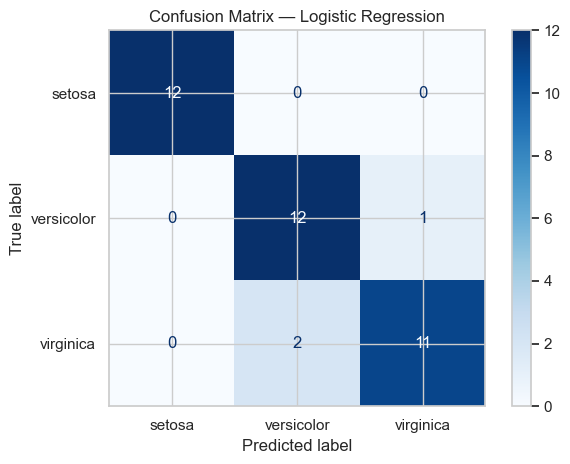

In [3]:
#Supervised: Logistic Regression classifier
#Pipeline: StandardScaler → LogisticRegression

#Split train/test; compute accuracy, confusion matrix, and classification report.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression"); plt.tight_layout(); plt.show()

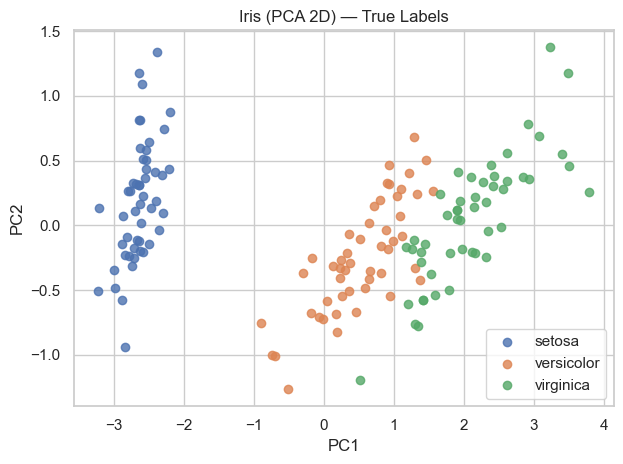

In [4]:
#Visualize true classes (PCA 2D)
pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X)

plt.figure()
for i, name in enumerate(target_names):
    plt.scatter(X2[y==i,0], X2[y==i,1], label=name, alpha=0.8)
plt.title("Iris (PCA 2D) — True Labels")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.tight_layout(); plt.show()

k-Means: silhouette=0.460 (−1..1), ARI vs true labels=0.620 (0..1)


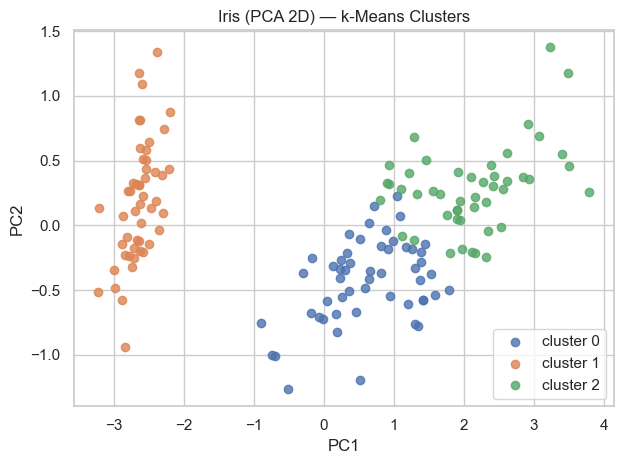

In [5]:
#Unsupervised: k‑Means clustering (k=3)
"""Pipeline: StandardScaler → KMeans(n_clusters=3)

Evaluate with silhouette (internal) and Adjusted Rand Index vs true labels (external, just for learning).

Visualize clusters on the same PCA plane."""

pipe_km = make_pipeline(StandardScaler(), KMeans(n_clusters=3, n_init=20, random_state=0))
labels_km = pipe_km.fit_predict(X)

# Internal metric
sil = silhouette_score(StandardScaler().fit_transform(X), pipe_km.named_steps['kmeans'].labels_)
# External metric (teaching aid)
ari = adjusted_rand_score(y, labels_km)

print(f"k-Means: silhouette={sil:.3f} (−1..1), ARI vs true labels={ari:.3f} (0..1)")

plt.figure()
for k in range(3):
    plt.scatter(X2[labels_km==k,0], X2[labels_km==k,1], label=f'cluster {k}', alpha=0.8)
plt.title("Iris (PCA 2D) — k-Means Clusters")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.tight_layout(); plt.show()


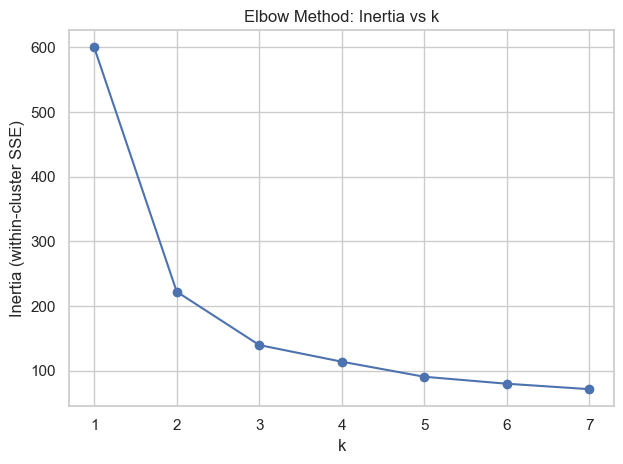

In [6]:
#Elbow method (choose k)
X_scaled = StandardScaler().fit_transform(X)
ks, inertias = range(1, 8), []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(ks), inertias, marker='o')
plt.title("Elbow Method: Inertia vs k")
plt.xlabel("k"); plt.ylabel("Inertia (within-cluster SSE)")
plt.tight_layout(); plt.show()

LogisticRegression — Test Accuracy: 0.921


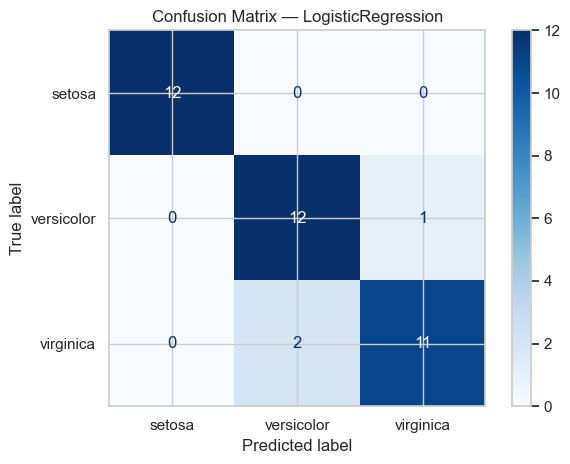

SVM (RBF) — Test Accuracy: 0.947


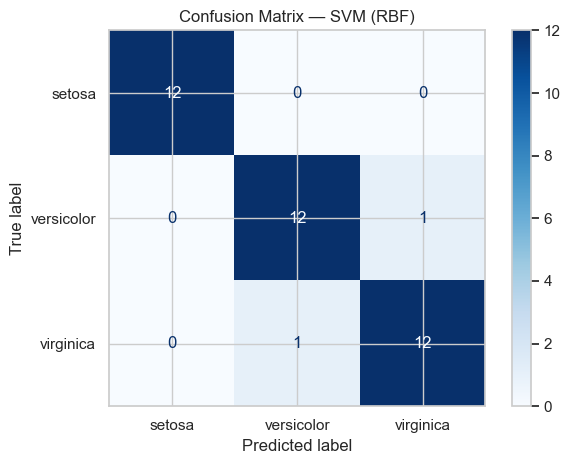

k-NN — Test Accuracy: 0.921


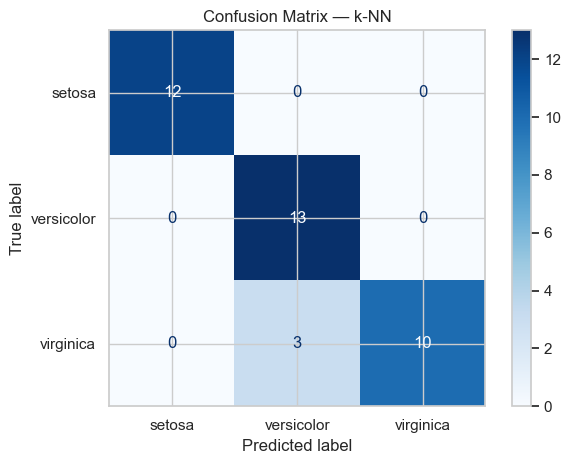

In [7]:
# Compare Logistic Regression with SVM (RBF) and k-NN
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'SVM (RBF)': make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=0)),
    'k-NN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} — Test Accuracy: {acc:.3f}")
    cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot(cmap='Blues')
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout(); plt.show()

 k    inertia      silhouette
 2       222.36        0.582
 3       139.82        0.460
 4       114.09        0.387
 5        90.81        0.346
 6        80.02        0.326


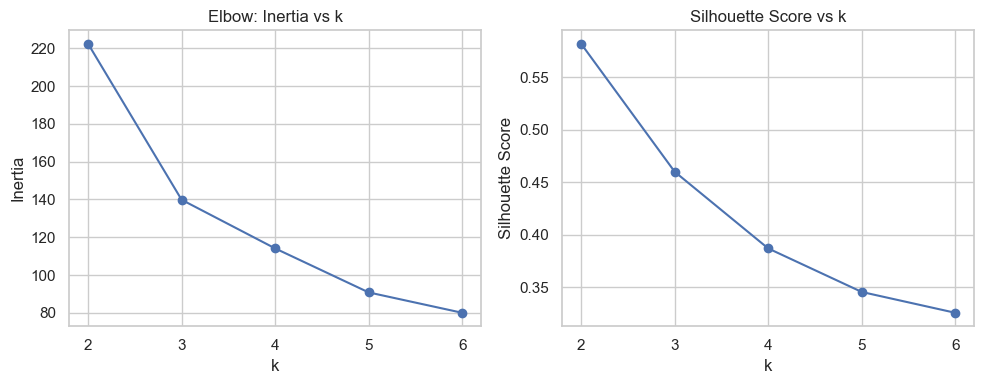

Chosen k (highest silhouette) = 2 (silhouette=0.582)
Justification: pick the k that balances a high silhouette score with the elbow in the inertia plot — inspect the two plots above for the elbow location.


In [8]:
# k-Means: evaluate k=2..6 with inertia and silhouette
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_scaled = StandardScaler().fit_transform(X)
ks = list(range(2, 7))
inertias = []
sils = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

# Print results table
print(' k    inertia      silhouette')
for k, i, s in zip(ks, inertias, sils):
    print(f'{k:2d} {i:12.2f} {s:12.3f}')

# Plot inertia (elbow) and silhouette together
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, marker='o')
plt.title('Elbow: Inertia vs k')
plt.xlabel('k'); plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(ks, sils, marker='o')
plt.title('Silhouette Score vs k')
plt.xlabel('k'); plt.ylabel('Silhouette Score')
plt.tight_layout(); plt.show()

# Choose k: prefer high silhouette and an elbow in inertia
best_k_sil = ks[sils.index(max(sils))]
print(f'Chosen k (highest silhouette) = {best_k_sil} (silhouette={max(sils):.3f})')
print('Justification: pick the k that balances a high silhouette score with the elbow in the inertia plot — inspect the two plots above for the elbow location.')

k-Means on original 4D features:
  silhouette = 0.460, ARI vs true = 0.620
k-Means on PCA (2 PCs):
  silhouette = 0.504, ARI vs true = 0.532


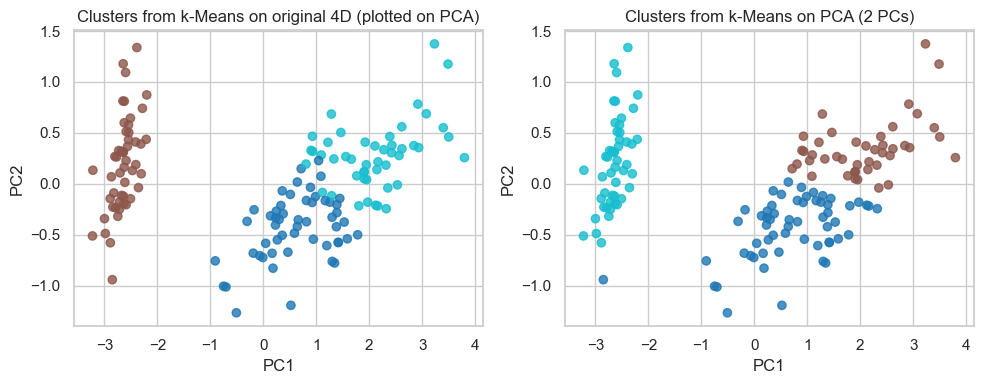

Note: higher silhouette indicates tighter, well-separated clusters; ARI measures agreement with true labels (higher is better).


In [9]:
# Cluster on PCA-reduced features (2 PCs) and compare silhouette & ARI
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Recompute 2-component PCA (X2 may already exist earlier)
pca2 = PCA(n_components=2, random_state=0)
X_pca2 = pca2.fit_transform(X)

# Prepare data: scaled original (4-d) and PCA-reduced (2-d)
X_scaled = StandardScaler().fit_transform(X)
X_pca_scaled = StandardScaler().fit_transform(X_pca2)

k = 3
km_orig = KMeans(n_clusters=k, n_init=20, random_state=0).fit(X_scaled)
labels_orig = km_orig.labels_
sil_orig = silhouette_score(X_scaled, labels_orig)
ari_orig = adjusted_rand_score(y, labels_orig)

km_pca = KMeans(n_clusters=k, n_init=20, random_state=0).fit(X_pca_scaled)
labels_pca = km_pca.labels_
sil_pca = silhouette_score(X_pca_scaled, labels_pca)
ari_pca = adjusted_rand_score(y, labels_pca)

print('k-Means on original 4D features:')
print(f'  silhouette = {sil_orig:.3f}, ARI vs true = {ari_orig:.3f}')
print('k-Means on PCA (2 PCs):')
print(f'  silhouette = {sil_pca:.3f}, ARI vs true = {ari_pca:.3f}')

# Visualize clustering results on the PCA plane for easy comparison
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels_orig, cmap='tab10', alpha=0.8)
plt.title('Clusters from k-Means on original 4D (plotted on PCA)')
plt.xlabel('PC1'); plt.ylabel('PC2')

plt.subplot(1,2,2)
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels_pca, cmap='tab10', alpha=0.8)
plt.title('Clusters from k-Means on PCA (2 PCs)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout(); plt.show()

print('Note: higher silhouette indicates tighter, well-separated clusters; ARI measures agreement with true labels (higher is better).')

k = 3
k-Means   — silhouette=0.504, ARI=0.532
Agglomerative (Ward) — silhouette=0.499, ARI=0.561


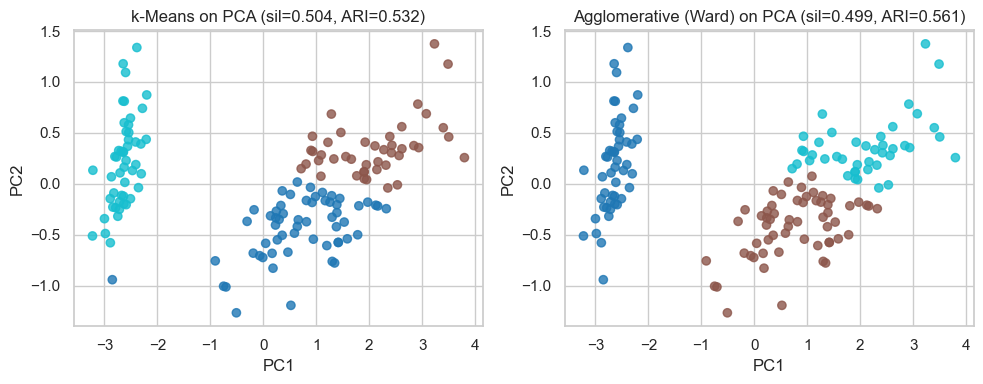

Interpretation: compare silhouette (higher is better) for compactness and ARI for agreement with true labels.


In [10]:
# Compare AgglomerativeClustering (Ward) vs k-Means on PCA plane
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Use PCA-reduced features (2 PCs) for plotting and fair comparison
pca2 = PCA(n_components=2, random_state=0)
X_pca2 = pca2.fit_transform(X)
X_pca_scaled = StandardScaler().fit_transform(X_pca2)

k = 3
# k-Means on PCA features
km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(X_pca_scaled)
labels_km = km.labels_
sil_km = silhouette_score(X_pca_scaled, labels_km)
ari_km = adjusted_rand_score(y, labels_km)

# Agglomerative (Ward) on PCA features
agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X_pca_scaled)
labels_agg = agg.labels_
sil_agg = silhouette_score(X_pca_scaled, labels_agg)
ari_agg = adjusted_rand_score(y, labels_agg)

print('k =', k)
print(f'k-Means   — silhouette={sil_km:.3f}, ARI={ari_km:.3f}')
print(f'Agglomerative (Ward) — silhouette={sil_agg:.3f}, ARI={ari_agg:.3f}')

# Plot clusters on PCA plane side-by-side
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels_km, cmap='tab10', alpha=0.8)
plt.title(f'k-Means on PCA (sil={sil_km:.3f}, ARI={ari_km:.3f})')
plt.xlabel('PC1'); plt.ylabel('PC2')

plt.subplot(1,2,2)
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels_agg, cmap='tab10', alpha=0.8)
plt.title(f'Agglomerative (Ward) on PCA (sil={sil_agg:.3f}, ARI={ari_agg:.3f})')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout(); plt.show()

print('Interpretation: compare silhouette (higher is better) for compactness and ARI for agreement with true labels.')